# EDA with Python and applying Logistic Regression

for this lecture we will be working with the Titanic Data Set From Kaggle. This is a very famous data set and very often is a students first step in machine


We will be trying to predict a classification survival deceased. Lets begin our understandingg of implementing Logistic Regression in Python for Classification.

We will use a "semi-cleaned" version of the titanic dataset. if you use the dataset hosted directly on kaggle, you may need to do some additional cleaning not shown in this lecture notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**The data**

Lets start by reading in the titanic_train.csv file into a pandas dataframe

In [2]:
import kagglehub
path = kagglehub.dataset_download("yasserh/titanic-dataset")

C:\Users\rajsh\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
train=pd.read_csv(os.path.join(path, 'Titanic-Dataset.csv'))

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Exploratory Data Analysis**

Let's begin some exploratory data analysis! We'll start by checking out missing data!

**Missing Data**

We can use seaborn to create a simple heatmap to see where we are missing data!

In [5]:
train.isnull()
#train.isnull() shows you exactly where your dataset has missing values. It returns True for every missing piece of data and False otherwise.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

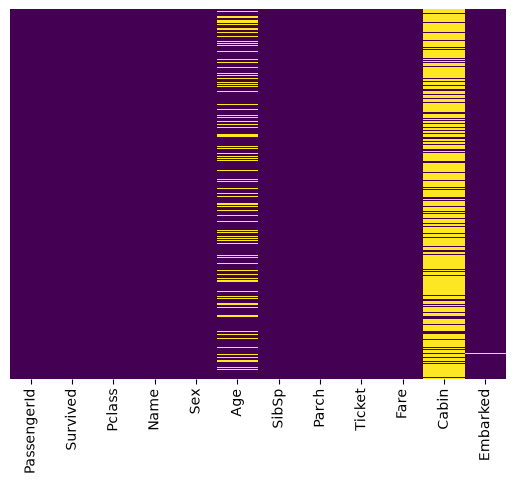

In [6]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

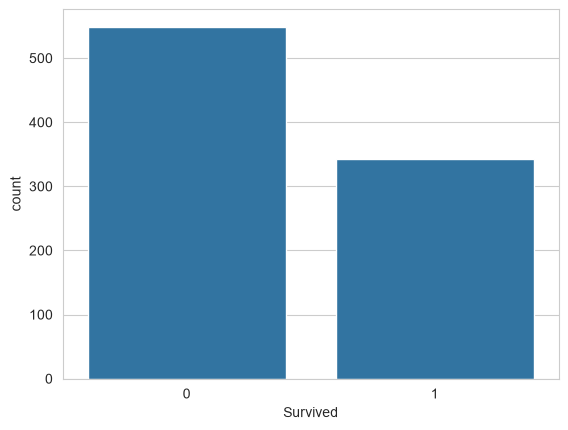

In [7]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train)

<Axes: xlabel='Survived', ylabel='count'>

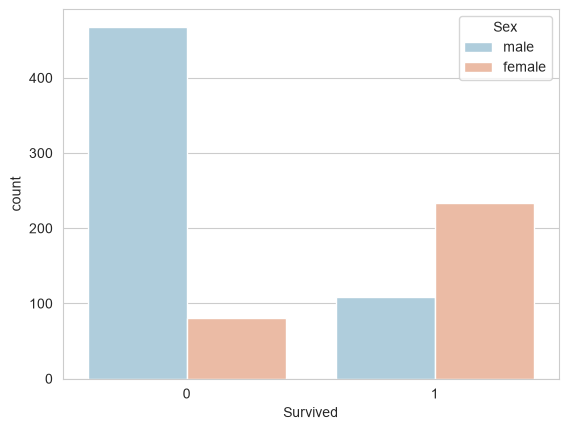

In [8]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train, palette='RdBu_r')
#In the countplot we just used, hue='Sex' meant that the bars for 'Survived' (0 or 1) were further split and colored based on whether the passenger was 'male' or 'female'. This allowed us to see not just the total count of survivors and non-survivors, but also how those counts were distributed between males and females.

In the countplot we just used, hue='Sex' meant that the bars for 'Survived' (0 or 1) were further split and colored based on whether the passenger was 'male' or 'female'. This allowed us to see not just the total count of survivors and non-survivors, but also how those counts were distributed between males and females.

<Axes: xlabel='Survived', ylabel='count'>

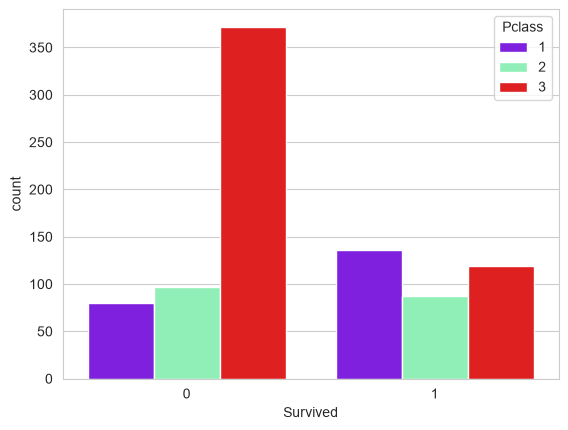

In [9]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=train, palette='rainbow')

C:\Users\rajsh\AppData\Local\Temp\ipykernel_9868\1259507556.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(),kde=False, color='darkred', bins=40)


<Axes: xlabel='Age'>

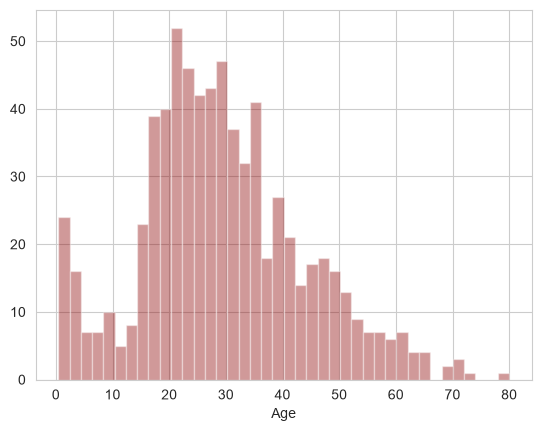

In [10]:
#distributon of the age
sns.distplot(train['Age'].dropna(),kde=False, color='darkred', bins=40)

#kde stands for kernel density distribution, it is set to false ie user dont want to show this